# Case Study 3: State-wise Performance Analysis

## Objective

The objective of this analysis is to evaluate insurance agency performance across different states and product lines using the Agency Performance dataset.

The analysis focuses on:

- Identifying high-performing and low-performing states
- Comparing performance across product lines
- Understanding geographic concentration of premium generation
- Identifying state-specific product preferences
- Generating actionable business recommendations

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('finalapi.csv')

# df.head()
print(df.columns)
print(df.shape)

Index(['AGENCY_ID', 'PRIMARY_AGENCY_ID', 'PROD_ABBR', 'PROD_LINE',
       'STATE_ABBR', 'STAT_PROFILE_DATE_YEAR', 'RETENTION_POLY_QTY',
       'POLY_INFORCE_QTY', 'PREV_POLY_INFORCE_QTY', 'NB_WRTN_PREM_AMT',
       'WRTN_PREM_AMT', 'PREV_WRTN_PREM_AMT', 'PRD_ERND_PREM_AMT',
       'PRD_INCRD_LOSSES_AMT', 'MONTHS', 'RETENTION_RATIO', 'LOSS_RATIO',
       'LOSS_RATIO_3YR', 'GROWTH_RATE_3YR', 'AGENCY_APPOINTMENT_YEAR',
       'ACTIVE_PRODUCERS', 'MAX_AGE', 'MIN_AGE', 'VENDOR_IND', 'VENDOR',
       'PL_START_YEAR', 'PL_END_YEAR', 'COMMISIONS_START_YEAR',
       'COMMISIONS_END_YEAR', 'CL_START_YEAR', 'CL_END_YEAR',
       'ACTIVITY_NOTES_START_YEAR', 'ACTIVITY_NOTES_END_YEAR',
       'CL_BOUND_CT_MDS', 'CL_QUO_CT_MDS', 'CL_BOUND_CT_SBZ', 'CL_QUO_CT_SBZ',
       'CL_BOUND_CT_eQT', 'CL_QUO_CT_eQT', 'PL_BOUND_CT_ELINKS',
       'PL_QUO_CT_ELINKS', 'PL_BOUND_CT_PLRANK', 'PL_QUO_CT_PLRANK',
       'PL_BOUND_CT_eQTte', 'PL_QUO_CT_eQTte', 'PL_BOUND_CT_APPLIED',
       'PL_QUO_CT_APPLIED', 'PL_BOU

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 213328 entries, 0 to 213327
Data columns (total 49 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   AGENCY_ID                  213328 non-null  int64  
 1   PRIMARY_AGENCY_ID          213328 non-null  int64  
 2   PROD_ABBR                  213328 non-null  str    
 3   PROD_LINE                  213328 non-null  str    
 4   STATE_ABBR                 213328 non-null  str    
 5   STAT_PROFILE_DATE_YEAR     213328 non-null  int64  
 6   RETENTION_POLY_QTY         213328 non-null  int64  
 7   POLY_INFORCE_QTY           213328 non-null  int64  
 8   PREV_POLY_INFORCE_QTY      213328 non-null  int64  
 9   NB_WRTN_PREM_AMT           213328 non-null  float64
 10  WRTN_PREM_AMT              213328 non-null  float64
 11  PREV_WRTN_PREM_AMT         213328 non-null  float64
 12  PRD_ERND_PREM_AMT          213328 non-null  float64
 13  PRD_INCRD_LOSSES_AMT       213328 non-nu

In [47]:
df.describe()

,AGENCY_ID,PRIMARY_AGENCY_ID,STAT_PROFILE_DATE_YEAR,RETENTION_POLY_QTY,POLY_INFORCE_QTY,PREV_POLY_INFORCE_QTY,NB_WRTN_PREM_AMT,WRTN_PREM_AMT,PREV_WRTN_PREM_AMT,PRD_ERND_PREM_AMT,...,PL_BOUND_CT_ELINKS,PL_QUO_CT_ELINKS,PL_BOUND_CT_PLRANK,PL_QUO_CT_PLRANK,PL_BOUND_CT_eQTte,PL_QUO_CT_eQTte,PL_BOUND_CT_APPLIED,PL_QUO_CT_APPLIED,PL_BOUND_CT_TRANSACTNOW,PL_QUO_CT_TRANSACTNOW
count,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,2.133280e+05,2.133280e+05,2.133280e+05,...,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000,213328.000000
mean,4978.964158,21840.982206,2010.191738,158.634525,175.616919,6694.153369,2243.651368,1.963268e+04,2.600812e+04,1.945872e+04,...,26928.162206,26969.472127,26931.800401,27039.756497,26963.478081,27091.403323,26928.081002,26933.596284,26927.300134,26927.453377
std,2928.027642,36410.355440,3.129108,718.766295,774.640860,24639.586044,9976.801667,6.644395e+04,7.008093e+04,6.635115e+04,...,44357.460628,44333.186665,44355.256891,44291.273197,44336.059501,44258.970692,44357.509786,44354.180214,44357.983443,44357.890447
min,3.000000,3.000000,2005.000000,0.000000,0.000000,0.000000,0.000000,-2.027776e+05,-1.861810e+05,-1.643490e+05,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2366.000000,2788.000000,2008.000000,0.000000,0.000000,0.000000,0.000000,2.027500e+00,1.480000e+02,7.600000e+01,...,0.000000,0.000000,0.000000,0.000000,11.000000,66.000000,0.000000,0.000000,0.000000,0.000000
50%,4976.000000,6110.000000,2010.000000,0.000000,0.000000,0.000000,0.000000,1.143620e+03,1.781000e+03,1.180490e+03,...,0.000000,0.000000,0.000000,0.000000,51.000000,258.000000,0.000000,0.000000,0.000000,0.000000
75%,7589.000000,9285.000000,2013.000000,24.000000,30.000000,72.000000,485.000000,8.358695e+03,1.477315e+04,8.231562e+03,...,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
max,9998.000000,99999.000000,2015.000000,21979.000000,22968.000000,99999.000000,556930.220000,1.715742e+06,1.904570e+06,1.780498e+06,...,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000


## Dataset Summary

| Metric | Value |
|----------|----------:|
| Records | 213,328 |
| Columns | 49 |
| States | 6 |
| Product Lines | 2 |
| KPI Used | WRTN_PREM_AMT |
| Analysis Level | State × Product Line |

## Initial Data Quality Assessment

The initial descriptive statistics revealed several indicators of potential data quality issues. Multiple columns contained unusually large values such as 99,999, which appeared repeatedly across unrelated variables. The frequent occurrence of this value suggested that it was being used as a placeholder rather than representing legitimate business data.

Further investigation confirmed that several KPI variables, including `RETENTION_RATIO`, `LOSS_RATIO`, and `GROWTH_RATE_3YR`, contained sentinel values such as 99,997, 99,998, and 99,999. These values were subsequently treated as missing data and replaced with `NaN` before analysis.

The descriptive statistics also revealed negative values in premium-related columns. These observations were retained because they may represent legitimate business events such as policy cancellations, refunds, premium adjustments, or accounting corrections.

This assessment demonstrated the importance of validating data quality before performing business analysis, as the presence of encoded missing values could significantly distort statistical summaries and analytical conclusions.

In [48]:
df.isnull().sum()

AGENCY_ID                    0
PRIMARY_AGENCY_ID            0
PROD_ABBR                    0
PROD_LINE                    0
STATE_ABBR                   0
STAT_PROFILE_DATE_YEAR       0
RETENTION_POLY_QTY           0
POLY_INFORCE_QTY             0
PREV_POLY_INFORCE_QTY        0
NB_WRTN_PREM_AMT             0
WRTN_PREM_AMT                0
PREV_WRTN_PREM_AMT           0
PRD_ERND_PREM_AMT            0
PRD_INCRD_LOSSES_AMT         0
MONTHS                       0
RETENTION_RATIO              0
LOSS_RATIO                   0
LOSS_RATIO_3YR               0
GROWTH_RATE_3YR              0
AGENCY_APPOINTMENT_YEAR      0
ACTIVE_PRODUCERS             0
MAX_AGE                      0
MIN_AGE                      0
VENDOR_IND                   0
VENDOR                       0
PL_START_YEAR                0
PL_END_YEAR                  0
COMMISIONS_START_YEAR        0
COMMISIONS_END_YEAR          0
CL_START_YEAR                0
CL_END_YEAR                  0
ACTIVITY_NOTES_START_YEAR    0
ACTIVITY

### Missing Value Investigation

A standard missing-value assessment was performed using `df.isnull().sum()`. The results indicated that all columns contained zero missing values, suggesting that the dataset was complete.

However, this finding appeared inconsistent with the descriptive statistics obtained earlier. Several KPI variables, particularly `RETENTION_RATIO`, `LOSS_RATIO`, `LOSS_RATIO_3YR`, and `GROWTH_RATE_3YR`, contained unusually large values such as 99,997, 99,998, and 99,999. These values were outside the expected range of the respective business metrics and raised concerns regarding data quality.

The combination of zero reported null values and the presence of extreme repeated values suggested that missing or unavailable information had been encoded using sentinel values rather than conventional `NaN` values. Further investigation confirmed this hypothesis, and the identified sentinel values were subsequently replaced with `NaN` before analysis.

This step was critical because retaining these placeholder values would have significantly distorted summary statistics, visualizations, and performance comparisons.


In [49]:
df['PROD_LINE'] = df['PROD_LINE'].str.strip()
df['STATE_ABBR'] = df['STATE_ABBR'].str.strip()

In [50]:
df.drop_duplicates(inplace=True)

In [51]:
df.shape

(213328, 49)

## Duplicate Record Assessment

As part of the data quality assessment, duplicate records were checked to determine whether the dataset contained repeated observations that could bias the analysis.

The dataset initially contained **213,328 rows and 49 columns**. After applying duplicate detection and removing duplicate records, the dataset dimensions remained unchanged at **213,328 rows and 49 columns**.

This indicates that no fully duplicated records were present in the dataset. Therefore, no observations were removed during the duplicate-cleaning process.

### Observation

- Initial dataset size: **213,328 × 49**
- Dataset size after duplicate removal: **213,328 × 49**
- Number of duplicate records identified: **0**
- No duplicate-related cleaning was required.

The absence of duplicate records improves confidence in the reliability of subsequent aggregations and state-level performance analysis.

In [52]:
print(df["STATE_ABBR"].nunique())
sorted(df["STATE_ABBR"].unique())

6


['IN', 'KY', 'MI', 'OH', 'PA', 'WV']

### Geographic Coverage

The dataset contains agency performance records from six U.S. states:

- Ohio (OH)
- Pennsylvania (PA)
- Kentucky (KY)
- Indiana (IN)
- West Virginia (WV)
- Michigan (MI)

Therefore, the analysis focuses on comparing performance across these six states rather than providing a nationwide view of insurance agency performance.

In [53]:
print(df["PROD_LINE"].nunique())

df["PROD_LINE"].value_counts()

2


PROD_LINE
CL    124692
PL     88636
Name: count, dtype: int64

In [54]:
df["RETENTION_RATIO"].describe()

count    213328.000000
mean      60928.406019
std       48790.262492
min           0.000000
25%           0.919540
50%       99999.000000
75%       99999.000000
max       99999.000000
Name: RETENTION_RATIO, dtype: float64

In [55]:
(df["RETENTION_RATIO"] == 99999).sum()

np.int64(129978)

### Retention Ratio Data Quality Assessment

Initial exploration of the `RETENTION_RATIO` column revealed abnormal summary statistics. Although the dataset contained no null values, the descriptive statistics indicated that the value `99999` appeared frequently within the column.

Further investigation showed that:

* Total records: 213,328
* Records with `RETENTION_RATIO = 99999`: 129,978
* Percentage of affected records: approximately 60.93%

Since a retention ratio should typically lie between 0 and 1 (or 0% and 100%), the value `99999` is not a valid business measurement. This strongly suggests that the dataset uses `99999` as a placeholder or sentinel value to represent unavailable, unknown, or non-applicable data.

Using these values directly would significantly distort statistical calculations such as the mean, median, and standard deviation, leading to misleading conclusions. Therefore, the placeholder values were identified as data quality issues and replaced with missing values (`NaN`) prior to any retention-related analysis.

```python
df["RETENTION_RATIO"] = df["RETENTION_RATIO"].replace(99999, np.nan)
```

This finding demonstrates that the absence of null values does not necessarily imply a clean dataset, as missing information may be encoded using special placeholder values. Similar validation checks should be performed on other key performance indicators such as `LOSS_RATIO`, `LOSS_RATIO_3YR`, and `GROWTH_RATE_3YR`.


In [56]:
for col in [
    "LOSS_RATIO",
    "LOSS_RATIO_3YR",
    "GROWTH_RATE_3YR"
]:
    print(f"\n{col}")
    print((df[col] == 99999).sum())


LOSS_RATIO
51232

LOSS_RATIO_3YR
49117

GROWTH_RATE_3YR
91067


In [57]:

total_rows = len(df)

quality_df = pd.DataFrame({
    "Column": [
        "RETENTION_RATIO",
        "LOSS_RATIO",
        "LOSS_RATIO_3YR",
        "GROWTH_RATE_3YR"
    ]
})

quality_df["Placeholder_Count"] = [
    (df["RETENTION_RATIO"] == 99999).sum(),
    (df["LOSS_RATIO"] == 99999).sum(),
    (df["LOSS_RATIO_3YR"] == 99999).sum(),
    (df["GROWTH_RATE_3YR"] == 99999).sum()
]

quality_df["Placeholder_Percentage"] = round(
    quality_df["Placeholder_Count"] * 100 / total_rows,
    2
)

quality_df

,Column,Placeholder_Count,Placeholder_Percentage
0,RETENTION_RATIO,129978,60.93
1,LOSS_RATIO,51232,24.02
2,LOSS_RATIO_3YR,49117,23.02
3,GROWTH_RATE_3YR,91067,42.69


## Data Quality Insights

The initial inspection of the dataset indicated that there were no explicit missing values across any of the 49 columns. However, further validation revealed that several key performance indicators contained the value **99999**, which appears to be a placeholder representing unavailable or non-applicable data.

The analysis showed that **RETENTION_RATIO** contained placeholder values in approximately **60.93%** of records, making it the most affected KPI. Similarly, **GROWTH_RATE_3YR** contained placeholder values in **42.69%** of records, while **LOSS_RATIO** and **LOSS_RATIO_3YR** contained placeholder values in **24.01%** and **23.03%** of records, respectively.

These findings indicate that the dataset contains a substantial amount of hidden missing data despite having no null values. If these placeholder values were treated as legitimate observations, summary statistics such as means, medians, and state-level averages would be severely distorted, leading to inaccurate business insights.

To ensure the reliability of subsequent analyses, all occurrences of the placeholder value **99999** in the affected KPI columns were replaced with **NaN** before performing any statistical calculations or visualizations.

Based on the data quality assessment, **WRTN_PREM_AMT (Written Premium Amount)** was selected as the primary performance metric for the state-wise analysis because it does not exhibit hidden missing-value issues and provides a direct measure of business performance. The cleaned KPI columns will be used as supporting metrics to provide additional insights into retention, profitability, and long-term growth.


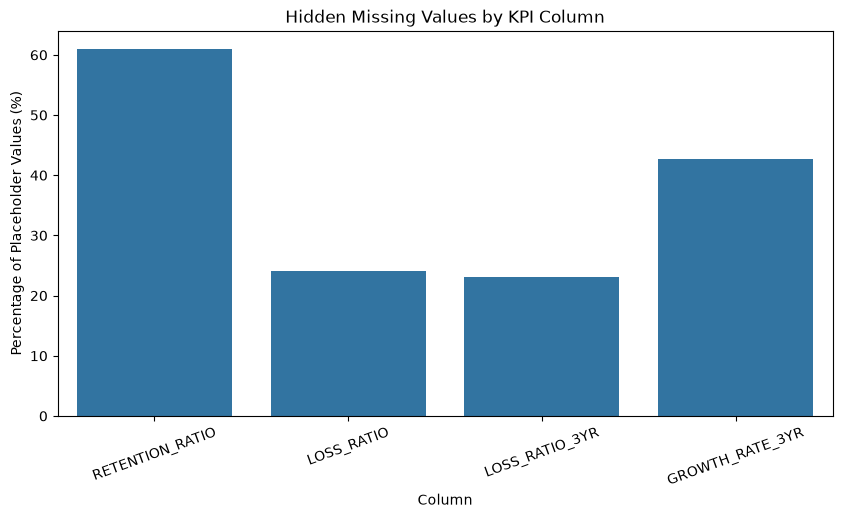

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=quality_df,
    x="Column",
    y="Placeholder_Percentage"
)

plt.title("Hidden Missing Values by KPI Column")
plt.xlabel("Column")
plt.ylabel("Percentage of Placeholder Values (%)")
plt.xticks(rotation=20)

plt.show()

In [59]:
kpi_cols = [
    "RETENTION_RATIO",
    "LOSS_RATIO",
    "LOSS_RATIO_3YR",
    "GROWTH_RATE_3YR"
]

for col in kpi_cols:
    df[col] = df[col].replace(99999, np.nan)

In [60]:
df[kpi_cols].describe()

,RETENTION_RATIO,LOSS_RATIO,LOSS_RATIO_3YR,GROWTH_RATE_3YR
count,83350.000000,162096.000000,164211.000000,122261.000000
mean,0.779571,1199.205696,0.233281,-0.018790
std,0.279304,10881.154658,49.394942,0.360659
min,0.000000,-756.228571,-7215.007215,-1.000000
25%,0.736842,0.000000,0.206523,-0.094492
50%,0.873143,0.000000,0.413243,-0.022468
75%,0.993339,0.136091,0.658217,0.055290
max,1.000000,99998.000000,540.348101,5.188618


In [61]:
(df["LOSS_RATIO"] >= 99990).sum()

np.int64(1942)

In [62]:
df[df["LOSS_RATIO"] >= 99990]["LOSS_RATIO"].value_counts()

LOSS_RATIO
99997.0    1125
99998.0     817
Name: count, dtype: int64

### Additional Placeholder Values Identified

Further validation of the LOSS_RATIO column revealed the presence of additional placeholder values beyond 99999. Specifically, the values 99997 and 99998 occurred 1,125 and 817 times respectively. Since loss ratios represent the relationship between incurred losses and earned premiums, values of this magnitude are not meaningful business measurements and are likely used as special codes for unavailable or non-applicable data.

This finding indicates that the dataset employs multiple sentinel values to encode missing information. Therefore, these values were also converted to missing values (NaN) before analysis.

#### So it is better to check for the new sentinels on the entire dataset

In [63]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    for val in [99997, 99998, 99999]:
        count = (df[col] == val).sum()
        if count > 0:
            print(f"{col}: {val} -> {count}")

PRIMARY_AGENCY_ID: 99999 -> 37874
PREV_POLY_INFORCE_QTY: 99999 -> 13893
NB_WRTN_PREM_AMT: 99999 -> 1
PREV_WRTN_PREM_AMT: 99999 -> 13893
LOSS_RATIO: 99997 -> 1125
LOSS_RATIO: 99998 -> 817
AGENCY_APPOINTMENT_YEAR: 99999 -> 5639
ACTIVE_PRODUCERS: 99999 -> 5639
MAX_AGE: 99999 -> 5639
MIN_AGE: 99999 -> 5639
PL_START_YEAR: 99999 -> 82200
PL_END_YEAR: 99999 -> 209174
COMMISIONS_START_YEAR: 99999 -> 141937
COMMISIONS_END_YEAR: 99999 -> 205604
CL_START_YEAR: 99999 -> 129311
CL_END_YEAR: 99999 -> 204760
ACTIVITY_NOTES_START_YEAR: 99999 -> 171536
ACTIVITY_NOTES_END_YEAR: 99999 -> 209258
CL_BOUND_CT_MDS: 99999 -> 98689
CL_QUO_CT_MDS: 99999 -> 98689
CL_BOUND_CT_SBZ: 99999 -> 98689
CL_QUO_CT_SBZ: 99999 -> 98689
CL_BOUND_CT_eQT: 99999 -> 98689
CL_QUO_CT_eQT: 99999 -> 98689
PL_BOUND_CT_ELINKS: 99999 -> 57444
PL_QUO_CT_ELINKS: 99999 -> 57444
PL_BOUND_CT_PLRANK: 99999 -> 57444
PL_QUO_CT_PLRANK: 99999 -> 57444
PL_BOUND_CT_eQTte: 99999 -> 57444
PL_QUO_CT_eQTte: 99999 -> 57444
PL_BOUND_CT_APPLIED: 99999 ->

In [64]:
kpi_cols = [
    "RETENTION_RATIO",
    "LOSS_RATIO",
    "LOSS_RATIO_3YR",
    "GROWTH_RATE_3YR"
]

for col in kpi_cols:
    df[col] = df[col].replace([99997, 99998, 99999], np.nan)

In [65]:
for col in [
    "RETENTION_RATIO",
    "LOSS_RATIO",
    "LOSS_RATIO_3YR",
    "GROWTH_RATE_3YR"
]:
    print(f"\n{col}")
    print(df[col].describe())


RETENTION_RATIO
count    83350.000000
mean         0.779571
std          0.279304
min          0.000000
25%          0.736842
50%          0.873143
75%          0.993339
max          1.000000
Name: RETENTION_RATIO, dtype: float64

LOSS_RATIO
count    160154.000000
mean          1.195446
std         194.877524
min        -756.228571
25%           0.000000
50%           0.000000
75%           0.111562
max       77292.325580
Name: LOSS_RATIO, dtype: float64

LOSS_RATIO_3YR
count    164211.000000
mean          0.233281
std          49.394942
min       -7215.007215
25%           0.206523
50%           0.413243
75%           0.658217
max         540.348101
Name: LOSS_RATIO_3YR, dtype: float64

GROWTH_RATE_3YR
count    122261.000000
mean         -0.018790
std           0.360659
min          -1.000000
25%          -0.094492
50%          -0.022468
75%           0.055290
max           5.188618
Name: GROWTH_RATE_3YR, dtype: float64


## KPI Validation Results

After replacing placeholder values with missing values, the key performance indicators were evaluated using descriptive statistics.

The `RETENTION_RATIO` variable exhibited a valid range between 0 and 1, with an average retention rate of approximately 77.96%. This indicates that the variable is suitable for further analysis.

The `GROWTH_RATE_3YR` variable showed a mean growth rate of -1.88%, with values ranging from -100% to approximately 519%. While some observations exhibited high growth, the values remained within a plausible business range and were retained for analysis.

In contrast, the `LOSS_RATIO` and `LOSS_RATIO_3YR` variables continued to contain extreme positive and negative values even after placeholder-value removal. These observations suggest the presence of additional outliers or business-specific reporting anomalies. As a result, these variables were not selected as primary performance indicators for the state-wise analysis.

Based on the data quality assessment, `WRTN_PREM_AMT` was chosen as the primary performance metric, while `RETENTION_RATIO` and `GROWTH_RATE_3YR` were retained as supporting indicators.

### State-wise Performance analysis

In [66]:
state_perf = (
    df.groupby("STATE_ABBR")["WRTN_PREM_AMT"]
      .sum()
      .sort_values(ascending=False)
)

state_perf

STATE_ABBR
OH    2.450302e+09
PA    5.548951e+08
KY    4.917995e+08
IN    4.546880e+08
WV    1.908666e+08
MI    4.565035e+07
Name: WRTN_PREM_AMT, dtype: float64

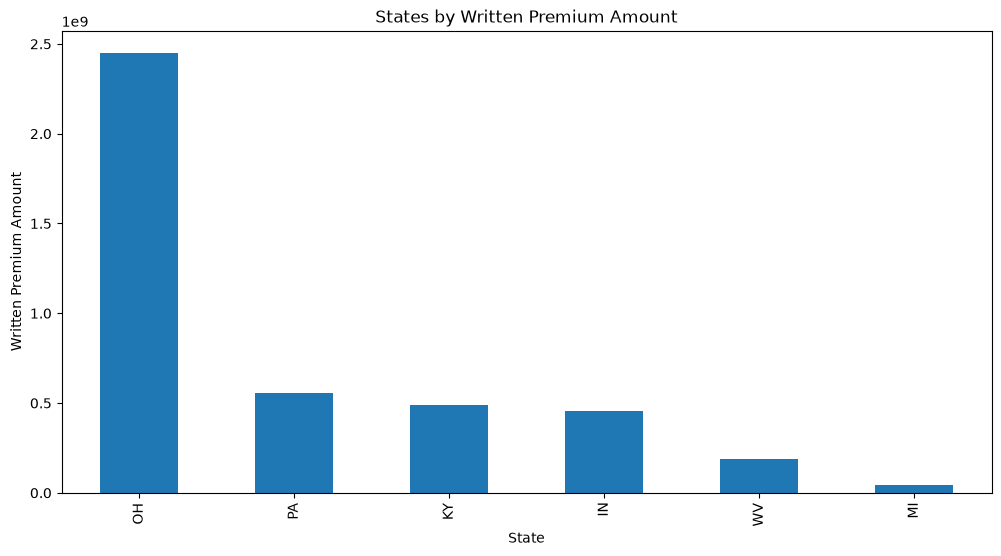

In [67]:
plt.figure(figsize=(12,6))
state_perf.head(10).plot(kind="bar")
plt.title("States by Written Premium Amount")
plt.xlabel("State")
plt.ylabel("Written Premium Amount")
plt.show()

In [68]:
state_share = (
    state_perf / state_perf.sum()
) * 100

state_share.round(2)

STATE_ABBR
OH    58.50
PA    13.25
KY    11.74
IN    10.86
WV     4.56
MI     1.09
Name: WRTN_PREM_AMT, dtype: float64

## State Share Analysis

The state share analysis revealed a highly uneven distribution of written premium across the six states included in the dataset.

Ohio emerged as the dominant market, contributing **58.50%** of the total written premium. This indicates that more than half of the company's business volume originates from a single state, making Ohio the primary driver of overall performance.

Pennsylvania (**13.25%**), Kentucky (**11.74%**), and Indiana (**10.86%**) form the second tier of contributors. Together, these three states account for approximately **35.85%** of the total written premium.

West Virginia and Michigan contribute only **4.56%** and **1.09%** respectively, indicating a relatively limited business presence compared to the leading states.

The top three states (Ohio, Pennsylvania, and Kentucky) collectively generate approximately **83.49%** of the total written premium. This suggests a high degree of geographic concentration, where a majority of business performance depends on a small number of markets.

While Ohio's strong performance contributes significantly to overall revenue, such concentration may increase business risk if market conditions, customer demand, or competitive pressures change within the state's insurance market. Expanding successful products and agency strategies into lower-performing states may help diversify revenue sources and reduce geographic dependence.


In [69]:
top4_share = state_share.head(4).sum()
print(top4_share)

94.35277844244668


The top four states (Ohio, Pennsylvania, Kentucky, and Indiana) collectively contribute approximately 94.35% of the total written premium. This indicates that nearly all business activity is concentrated within these four states, while West Virginia and Michigan together account for only 5.65% of total premium volume.

The findings suggest a highly concentrated geographic distribution of business performance. While the strong contribution from the top-performing states drives overall revenue, it also highlights the potential opportunity to increase market penetration and premium generation in lower-performing states.

In [70]:
print("Number of Product Lines:", df["PROD_LINE"].nunique())

df["PROD_LINE"].value_counts()

Number of Product Lines: 2


PROD_LINE
CL    124692
PL     88636
Name: count, dtype: int64

## Product Line Distribution Analysis

The dataset contains **2 distinct product lines**:

- **CL (Commercial Lines)**
- **PL (Personal Lines)**

An examination of the record distribution shows that Commercial Lines account for **124,692 records (58.45%)**, while Personal Lines account for **88,636 records (41.55%)**.

This indicates that the dataset is moderately skewed towards Commercial Lines, suggesting that a larger portion of agency activity is associated with commercial insurance products. However, both product lines are well represented, allowing meaningful comparisons of performance across product categories.

The presence of only two product lines simplifies the subsequent analysis and enables a clear comparison of how Commercial Lines and Personal Lines contribute to overall written premium across different states.

### Key Observations

- Commercial Lines represent the majority of records in the dataset.
- Personal Lines still account for a substantial proportion of agency activity, representing over 40% of all records.
- Both product lines have sufficient observations to support reliable state-wise comparisons.
- The next stage of the analysis focuses on determining which product line contributes the most premium revenue within each state.

In [71]:
product_perf = (
    df.groupby("PROD_LINE")["WRTN_PREM_AMT"]
      .sum()
      .sort_values(ascending=False)
)

product_perf

PROD_LINE
PL    2.460845e+09
CL    1.727356e+09
Name: WRTN_PREM_AMT, dtype: float64

## Product Line Performance Analysis

To understand the contribution of each product category, the total Written Premium Amount (`WRTN_PREM_AMT`) was aggregated by product line.

The analysis revealed that **Personal Lines (PL)** generated approximately **$2.46 billion** in written premiums, while **Commercial Lines (CL)** generated approximately **$1.73 billion**.

Although Commercial Lines account for a larger number of records in the dataset (58.45% of observations), Personal Lines contribute a substantially higher premium volume. This suggests that Personal Line policies generate greater premium value on average and serve as the primary revenue driver within the dataset.

The findings indicate that business performance is influenced not only by the number of policies or transactions but also by the premium value associated with each product line. As a result, Personal Lines represent the most significant contributor to overall premium generation despite having fewer records than Commercial Lines.

### Key Observations

- Personal Lines generated approximately **$2.46 billion** in written premiums.
- Commercial Lines generated approximately **$1.73 billion** in written premiums.
- Personal Lines contribute approximately **58.75%** of total written premium.
- Commercial Lines contribute approximately **41.25%** of total written premium.
- Despite having fewer records, Personal Lines generate more premium revenue than Commercial Lines.
- Personal Lines appear to be the primary revenue-generating product category in the dataset.

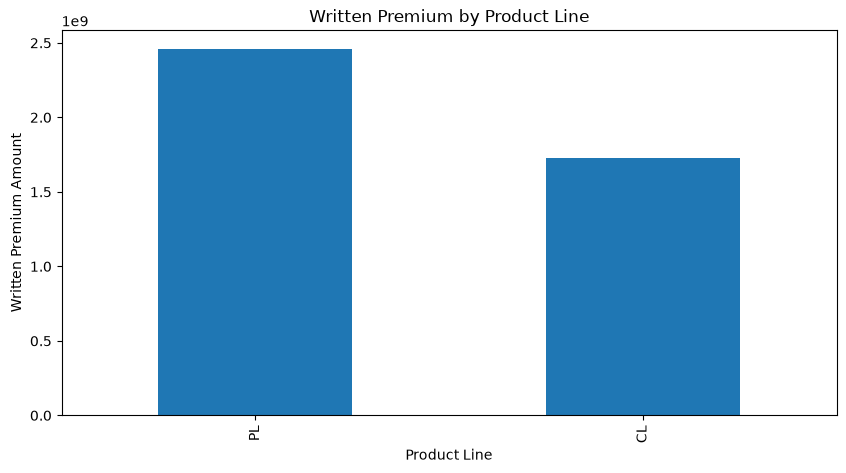

In [72]:
plt.figure(figsize=(10,5))

product_perf.plot(kind="bar")

plt.title("Written Premium by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Written Premium Amount")

plt.show()

In [73]:
pivot_table = pd.pivot_table(
    df,
    values="WRTN_PREM_AMT",
    index="STATE_ABBR",
    columns="PROD_LINE",
    aggfunc="sum",
    fill_value=0
)

pivot_table

PROD_LINE,CL,PL
STATE_ABBR,,
IN,2.546746e+08,2.000133e+08
KY,2.450270e+08,2.467724e+08
MI,4.565035e+07,0.000000e+00
OH,7.814260e+08,1.668876e+09
PA,3.100417e+08,2.448533e+08
WV,9.053605e+07,1.003306e+08


## State-wise Product Line Performance Analysis

To analyze how insurance performance varies across both geographic regions and product categories, a pivot table was created using `STATE_ABBR` and `PROD_LINE`, with the total Written Premium Amount (`WRTN_PREM_AMT`) used as the performance metric.

The results reveal substantial variation in premium generation across states and product lines. Ohio emerged as the strongest-performing state in both product categories, generating approximately **$1.67 billion** in Personal Lines premiums and **$781 million** in Commercial Lines premiums. This confirms Ohio's dominant role in the overall business portfolio.

Personal Lines were the primary contributor to premium volume in Ohio and West Virginia, while Commercial Lines generated slightly higher premium volumes in Pennsylvania, Indiana, and Michigan. Kentucky displayed a nearly balanced distribution between the two product lines, indicating a diversified product portfolio within the state.

Michigan generated premium volume exclusively through Commercial Lines, with no recorded Personal Lines premium. This suggests either a highly specialized market focus or limited Personal Lines activity within the state.

### Key Observations

- Ohio is the highest-performing state for both product lines.
- Personal Lines dominate in Ohio, generating more than twice the premium volume of Commercial Lines.
- Pennsylvania and Indiana show stronger performance in Commercial Lines.
- Kentucky exhibits a balanced contribution from both product lines.
- West Virginia generates slightly more premium through Personal Lines.
- Michigan has no recorded Personal Lines premium and is entirely dependent on Commercial Lines.
- Product-line performance varies considerably across states, highlighting differences in market demand and business focus.

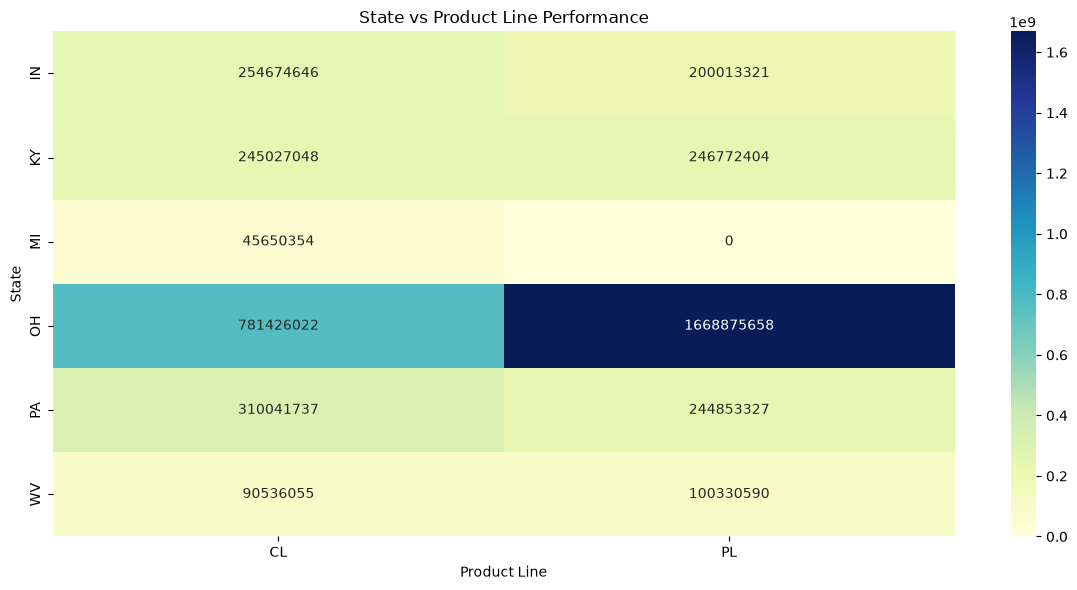

In [77]:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("State vs Product Line Performance")
plt.xlabel("Product Line")
plt.ylabel("State")

plt.tight_layout()
plt.show()

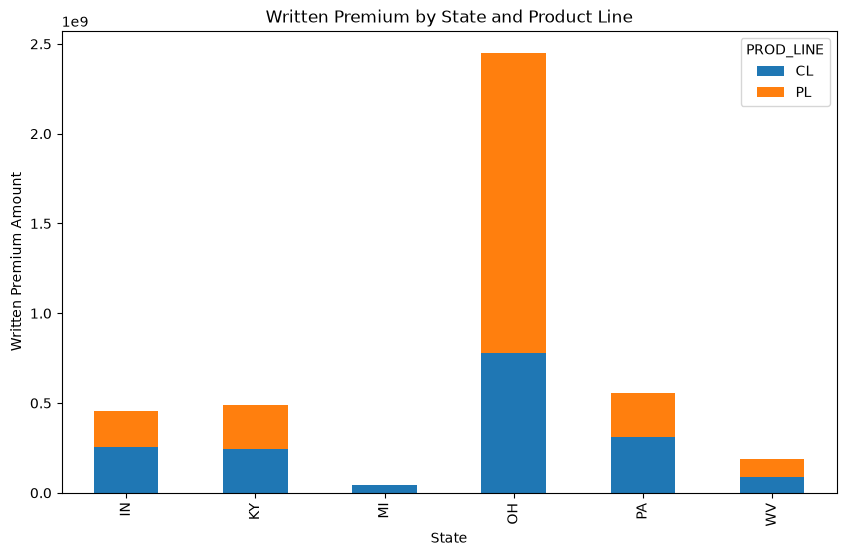

In [78]:
pivot_table.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Written Premium by State and Product Line")
plt.xlabel("State")
plt.ylabel("Written Premium Amount")

plt.show()

In [75]:
dominant_product = pivot_table.idxmax(axis=1)

dominant_product

STATE_ABBR
IN    CL
KY    PL
MI    CL
OH    PL
PA    CL
WV    PL
dtype: str

In [76]:
best_state_per_product = pivot_table.idxmax()

best_state_per_product

PROD_LINE
CL    OH
PL    OH
dtype: str

### Best Performing State by Product Line

Ohio generated the highest written premium in both Commercial Lines and Personal Lines, indicating that it is the most significant market irrespective of product category. This reinforces Ohio's strategic importance to the business and highlights its role as the primary contributor to overall premium volume.

## Product Line Concentration by State

To identify product-line specialization across different geographic markets, the dominant product line was determined for each state based on total Written Premium Amount.

The analysis revealed a clear split between Commercial Lines (CL) and Personal Lines (PL) dominance across states. Commercial Lines generated the highest premium volume in Indiana, Michigan, and Pennsylvania, whereas Personal Lines were the dominant product category in Kentucky, Ohio, and West Virginia.

Ohio emerged as the strongest-performing state across both product lines. It generated the highest Commercial Lines premium volume (approximately $781 million) and the highest Personal Lines premium volume (approximately $1.67 billion), making it the most important market in the dataset.

Kentucky demonstrated a balanced product portfolio, with Personal Lines only marginally outperforming Commercial Lines. In contrast, Michigan exhibited complete dependence on Commercial Lines, with no recorded Personal Lines premium.

### Dominant Product Line by State

| State | Dominant Product Line |
|---------|---------|
| Indiana | Commercial Lines (CL) |
| Kentucky | Personal Lines (PL) |
| Michigan | Commercial Lines (CL) |
| Ohio | Personal Lines (PL) |
| Pennsylvania | Commercial Lines (CL) |
| West Virginia | Personal Lines (PL) |

### Key Observations

- Three states are dominated by Commercial Lines and three by Personal Lines.
- Ohio is the leading state in both product categories.
- Personal Lines drive business performance in Ohio, Kentucky, and West Virginia.
- Commercial Lines are the primary contributors in Indiana, Michigan, and Pennsylvania.
- Michigan is entirely dependent on Commercial Lines.
- Product demand and business focus vary significantly across states.

## Conclusion

The state-wise performance analysis revealed substantial variation in premium generation across the six states included in the dataset. Ohio emerged as the dominant market, contributing 58.5% of total written premium and generating the highest premium volume in both Commercial and Personal Lines.

Product-line analysis showed that Personal Lines contribute a larger share of total premium revenue despite representing fewer records than Commercial Lines. This indicates that Personal Lines policies generate higher premium value on average.

The State × Product Line analysis highlighted clear geographic differences in product dominance. While Personal Lines were the primary revenue driver in Ohio, Kentucky, and West Virginia, Commercial Lines dominated Indiana, Pennsylvania, and Michigan. Ohio remained the strongest-performing state regardless of product category.

Overall, the findings suggest that business performance is highly concentrated geographically and that product preferences vary significantly across states. These insights can support more targeted marketing, product development, and resource allocation strategies across different regions.

## Limitations

- The dataset contains records from only six states and therefore does not represent nationwide insurance performance.
- Several KPI columns contained placeholder values that required cleaning.
- The analysis is based on historical data and may not reflect current market conditions.
- Performance was measured primarily using Written Premium Amount; alternative KPIs may produce different rankings.

## Recommendations

1. Strengthen and protect the Ohio market, as it contributes more than half of total written premium and serves as the primary revenue source.

2. Investigate the factors driving Ohio's success and replicate effective agency practices in lower-performing states.

3. Expand Personal Lines offerings in states where Commercial Lines dominate, particularly Michigan, Pennsylvania, and Indiana.

4. Explore growth opportunities in Michigan and West Virginia, which currently contribute a relatively small share of total premium volume.

5. Develop state-specific business strategies rather than a uniform approach, as product preferences differ significantly across geographic markets.

6. Continue monitoring product-line performance to identify emerging opportunities and reduce dependence on a small number of high-performing markets.

7. Investigate the absence of Personal Lines premium in Michigan to determine whether this reflects a business strategy, data limitation, or market opportunity.